Understand Problem Statement
Input (X):
Study_Hours_per_Day, Attendance_Percentage, Previous_Grade, Assignments_Completed, Sleep_Hours, Internet_Usage_Hours,
Gender, Parental_Education, Study_Method
Output (y):
Exam_Score


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/student_data.csv")

load the data

In [4]:
df

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Gender,Parental_Education,Study_Method,Exam_Score
0,5.993428,88.892663,85.990332,2.0,3.000000,3.258024,Male,High School,Self Study,51.601336
1,4.723471,100.000000,78.869505,NaN,4.338301,NaN,Female,Graduate,Online,NaN
2,6.295377,54.021486,65.894456,2.0,5.761473,4.069592,Male,Postgraduate,Online,44.802864
3,8.046060,83.444539,55.295948,5.0,4.485643,4.440208,Male,Graduate,Online,47.074854
4,4.531693,65.240361,75.473350,7.0,5.628833,NaN,Female,Graduate,Online,57.447696
...,...,...,...,...,...,...,...,...,...,...
495,6.077820,70.783496,95.091393,7.0,4.406999,0.000000,Male,High School,Self Study,67.186764
496,2.925508,100.000000,95.922554,10.0,NaN,3.260942,NaN,High School,Online,72.224406
497,4.619323,84.612643,NaN,3.0,6.059305,1.441390,Male,NaN,Self Study,55.524814
498,3.248763,66.432315,80.360938,0.0,6.716892,3.024824,Female,High School,Coaching,54.601213


Basic Data Check

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours_per_Day    475 non-null    float64
 1   Attendance_Percentage  475 non-null    float64
 2   Previous_Grade         475 non-null    float64
 3   Assignments_Completed  475 non-null    float64
 4   Sleep_Hours            475 non-null    float64
 5   Internet_Usage_Hours   475 non-null    float64
 6   Gender                 475 non-null    object 
 7   Parental_Education     475 non-null    object 
 8   Study_Method           475 non-null    object 
 9   Exam_Score             475 non-null    float64
dtypes: float64(7), object(3)
memory usage: 39.2+ KB


gives a summary of the dataset and The dataset has 500 rows and 10 columns.
All columns are of type float64 (numeric values).
Each column has 475 non-null values, which means some data is missing.

In [6]:
df.shape

(500, 10)

give the number of rows and column present repectively

In [7]:
df.describe()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Exam_Score
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000
mean,5.006107,75.100260,66.294369,4.911579,6.613022,3.133252,54.504812
std,1.962718,14.061157,14.612682,3.077853,1.496233,1.533065,12.950884
min,0.000000,34.546700,26.134366,0.000000,3.000000,0.000000,13.137347
25%,3.590277,66.027157,55.947626,2.000000,5.518049,2.222140,45.413574
50%,5.020466,75.431172,66.152328,5.000000,6.713023,3.138811,54.788589
75%,6.279295,84.626742,75.495470,8.000000,7.646837,4.085099,62.655921
max,12.000000,100.000000,100.000000,10.000000,10.000000,7.890737,100.000000


statistical summary of all numerical columns  in which count give number of non missing value ,std give variance ,and min max give lowest and highest value

In [8]:
df.head()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Gender,Parental_Education,Study_Method,Exam_Score
0,5.993428,88.892663,85.990332,2.0,3.000000,3.258024,Male,High School,Self Study,51.601336
1,4.723471,100.000000,78.869505,NaN,4.338301,NaN,Female,Graduate,Online,NaN
2,6.295377,54.021486,65.894456,2.0,5.761473,4.069592,Male,Postgraduate,Online,44.802864
3,8.046060,83.444539,55.295948,5.0,4.485643,4.440208,Male,Graduate,Online,47.074854
4,4.531693,65.240361,75.473350,7.0,5.628833,NaN,Female,Graduate,Online,57.447696


gives first 5 rows from dataset

In [9]:
df.tail()

,Study_Hours_per_Day,Attendance_Percentage,Previous_Grade,Assignments_Completed,Sleep_Hours,Internet_Usage_Hours,Gender,Parental_Education,Study_Method,Exam_Score
495,6.077820,70.783496,95.091393,7.0,4.406999,0.000000,Male,High School,Self Study,67.186764
496,2.925508,100.000000,95.922554,10.0,NaN,3.260942,NaN,High School,Online,72.224406
497,4.619323,84.612643,NaN,3.0,6.059305,1.441390,Male,NaN,Self Study,55.524814
498,3.248763,66.432315,80.360938,0.0,6.716892,3.024824,Female,High School,Coaching,54.601213
499,2.234401,83.588742,73.887904,9.0,7.237213,2.471917,Female,Postgraduate,Self Study,81.586597


gives last 5 rows

Delete columns with all unique values

In [10]:
for col in df.columns:
    if df[col].nunique() == len(df):
        df.drop(columns=[col], inplace=True)

This code removes columns with all unique values because they don’t contribute to model learning (like ID columns).

Handling Null Values

In [11]:
df.isnull().sum()

,0
Study_Hours_per_Day,25
Attendance_Percentage,25
Previous_Grade,25
Assignments_Completed,25
Sleep_Hours,25
Internet_Usage_Hours,25
Gender,25
Parental_Education,25
Study_Method,25
Exam_Score,25


null value present

In [14]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    elif df[col].dtype == "float64":
        df[col].fillna(df[col].mean(), inplace=True)
    elif df[col].dtype == "int64":
        df[col].fillna(df[col].median(), inplace=True)

This code handles missing values by replacing them with mean or median, ensuring the dataset is clean and ready for model training

In [15]:
df.isnull().sum()

,0
Study_Hours_per_Day,0
Attendance_Percentage,0
Previous_Grade,0
Assignments_Completed,0
Sleep_Hours,0
Internet_Usage_Hours,0
Gender,0
Parental_Education,0
Study_Method,0
Exam_Score,0


now no null value is present

Check duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

dataset has no duplicate records

split categorical and numerical value

In [17]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(exclude="object").columns

we can apply appropriate preprocessing techniques to each type

Handling Error Values

In [18]:
df.replace(["?", "/", "unknown"], np.nan, inplace=True)

  invalid placeholder values into NaN

Outlier Handling (IQR Method)

In [19]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

removes outliers from numerical columns

univariate and bivariate analysis

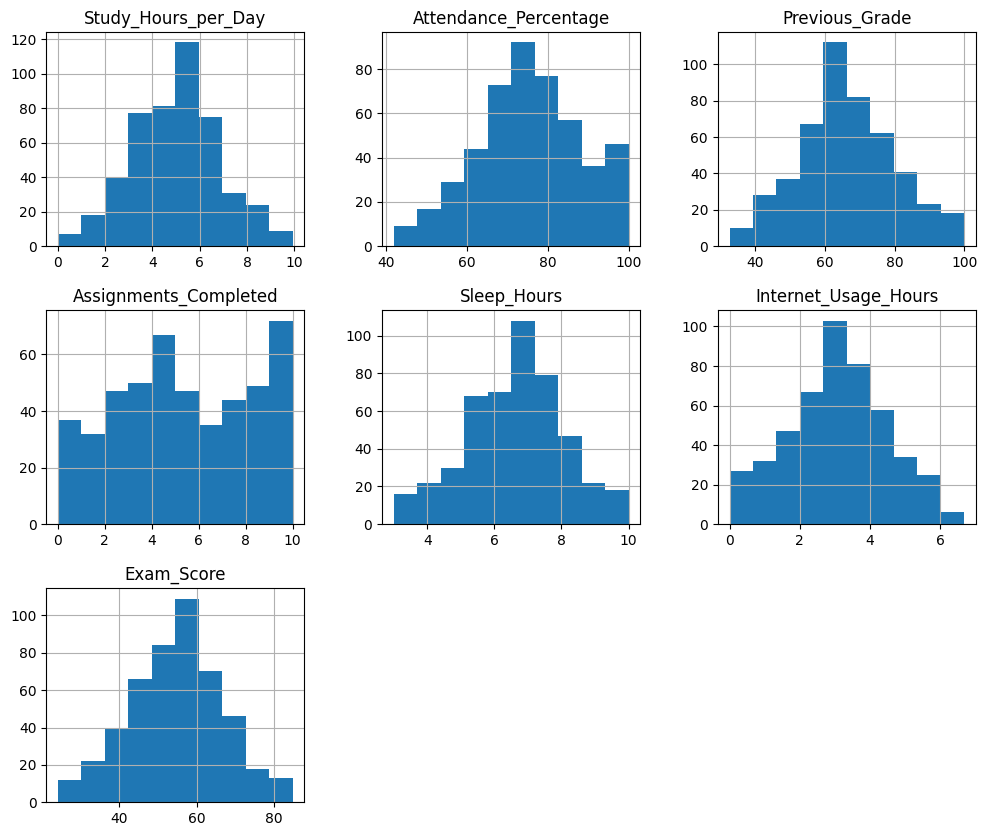

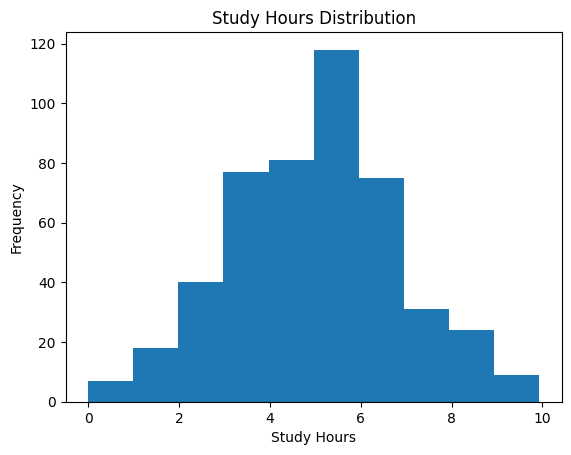

In [22]:
import matplotlib.pyplot as plt

# Histogram for all numerical columns
df.hist(figsize=(12,10))
plt.show()


plt.hist(df["Study_Hours_per_Day"])
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

Study_Hours_per_Day → Mostly between 3 to 7 hours
Attendance_Percentage → Concentrated around 60–90%
Previous_Grade → Mostly 50–80 marks
Assignments_Completed → Spread from 0 to 10
Sleep_Hours → Mostly 5–8 hours
Internet_Usage_Hours → Mostly 2–5 hours
Exam_Score → Centered around 50–65 marks

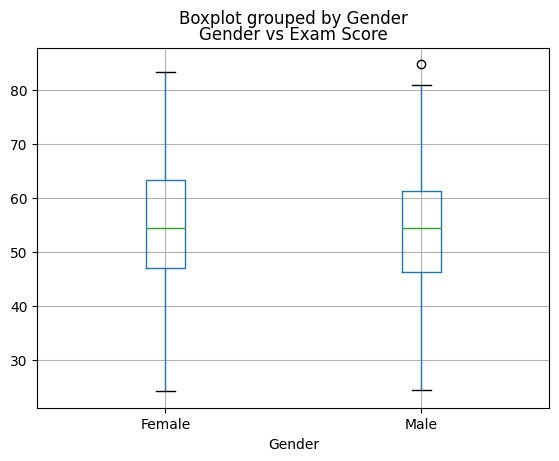

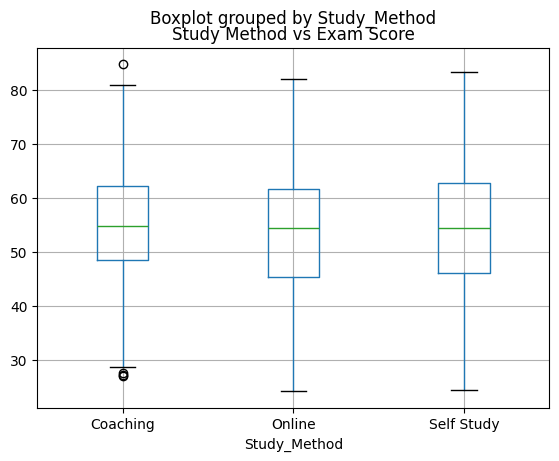

In [23]:
import matplotlib.pyplot as plt


df.boxplot(column="Exam_Score", by="Gender")
plt.title("Gender vs Exam Score")
plt.show()

df.boxplot(column="Exam_Score", by="Study_Method")
plt.title("Study Method vs Exam Score")
plt.show()

The boxplot shows that both genders have similar exam score distributions, indicating gender does not significantly impact performance.
The boxplot shows that all study methods result in similar exam performance, indicating no significant impact of study method on scores

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

This code converts categorical variables into numerical form using one-hot encoding while avoiding redundancy with drop_first

In [27]:
corr = df_encoded.corr()

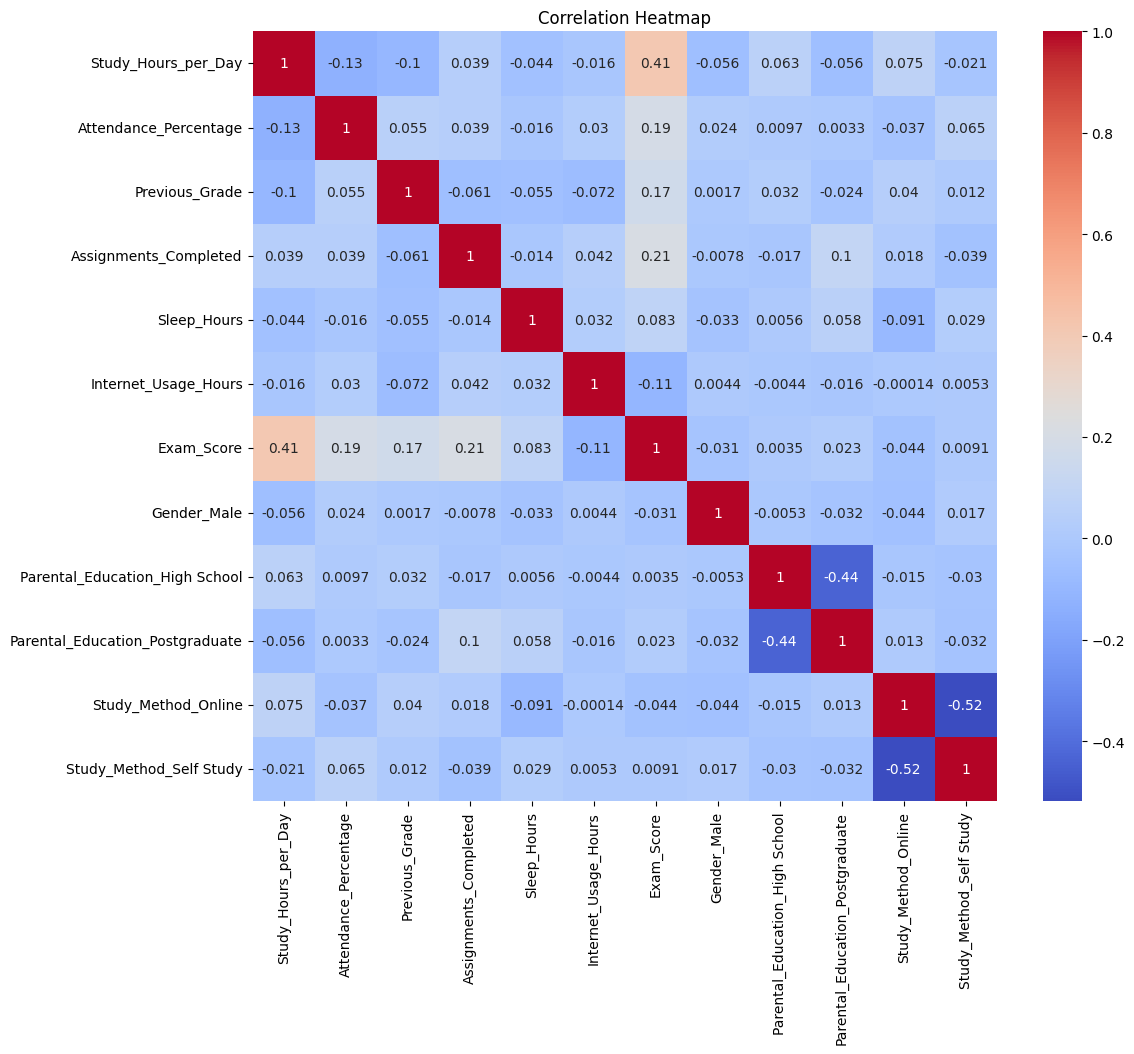

In [28]:
import seaborn as sns


plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that most features have weak correlation with exam score, with study hours being the most influential factor

Divide dataset into X and y

In [33]:
X = df_encoded.drop(columns=["Exam_Score"])
y = df_encoded["Exam_Score"]

separates features (input) and target (output) for model training.

exam_score is the target variable

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

splits the dataset into training and testing sets.

Initialize Model

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

imports and creates a Linear Regression model

In [36]:
model.fit(X_train, y_train)

LinearRegression()

step trains the model by learning the relationship between input features and exam scores

Model Evaluation (Regression)

In [37]:
y_pred = model.predict(X_test)

uses the trained model to predict exam scores for unseen test data.

Evaluation metrics

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 109.42280436895658
MAE: 8.554416428599131
R2 Score: 0.19633307249763077


These metrics show the model’s prediction error and accuracy, and here the low R² indicates the model performance is weak

improving model performance by using diffrent models

In [39]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Decision Tree
modeld = DecisionTreeRegressor(random_state=42)
modeld.fit(X_train, y_train)
y_pred_d = modeld.predict(X_test)

print("Decision Tree Results")
print("MSE:", mean_squared_error(y_test, y_pred_d))
print("MAE:", mean_absolute_error(y_test, y_pred_d))
print("R2 Score:", r2_score(y_test, y_pred_d))




Decision Tree Results
MSE: 198.59036152564468
MAE: 10.983089578062453
R2 Score: -0.45856712957887313


Decision tree is very weak model


In [40]:
# Random Forest
modelr = RandomForestRegressor(n_estimators=100, random_state=42)
modelr.fit(X_train, y_train)
y_pred_r = modelr.predict(X_test)

print("\nRandom Forest Results")
print("MSE:", mean_squared_error(y_test, y_pred_r))
print("MAE:", mean_absolute_error(y_test, y_pred_r))
print("R2 Score:", r2_score(y_test, y_pred_r))


Random Forest Results
MSE: 128.71270319239264
MAE: 9.305501890545647
R2 Score: 0.05465644659988911


random forest is also weak but better than decisioon tree

In [41]:

from sklearn.decomposition import PCA


pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# Decision Tree
modeld = DecisionTreeRegressor(random_state=42)
modeld.fit(X_train_pca, y_train)
y_pred_d = modeld.predict(X_test_pca)

print("\nDecision Tree with PCA")
print("MSE:", mean_squared_error(y_test, y_pred_d))
print("MAE:", mean_absolute_error(y_test, y_pred_d))
print("R2 Score:", r2_score(y_test, y_pred_d))





Decision Tree with PCA
MSE: 301.88774054682125
MAE: 13.526326510403054
R2 Score: -1.2172452469581114


PCA was applied to reduce dimensionality, but it did not significantly improve Decision Tree performance due to weak feature relationships.

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Parameter distribution
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Random Search
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

# Train
random_search.fit(X_train, y_train)

# Best model
modelr = random_search.best_estimator_

# Prediction
y_pred = modelr.predict(X_test)

# Evaluation
print("Best Parameters:", random_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10}
MSE: 119.58219767215085
MAE: 8.930845524942436
R2 Score: 0.12171637401002888


RandomizedSearchCV improved the Random Forest model performance, but the R² score remains low due to weak relationships in the dataset.

In [46]:

import pandas as pd

new_data = pd.DataFrame({
    "Study_Hours_per_Day": [4, 7, 2],
    "Attendance_Percentage": [70, 90, 60],
    "Previous_Grade": [65, 80, 50],
    "Assignments_Completed": [6, 9, 3],
    "Sleep_Hours": [6, 8, 5],
    "Internet_Usage_Hours": [3, 2, 5],

    # Dummy columns (may or may not match exactly)
    "Gender_Male": [1, 0, 1],
    "Parental_Education_Graduate": [1, 0, 0],
    "Parental_Education_Postgraduate": [0, 1, 0],
    "Study_Method_Online": [0, 1, 0],
    "Study_Method_Self Study": [1, 0, 1]
})

## (Fix column mismatch)
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

# Predict
predictions = model.predict(new_data)

# Output
print("Predicted Exam Scores:", predictions)

Predicted Exam Scores: [51.17479388 71.31765867 34.62523555]


This code predicts exam scores for new students using the trained model, ensuring feature consistency with reindexing.